In [6]:
import rasterio
import numpy as np
import glob
import os
import csv
import random
import datetime
import matplotlib.pyplot as plt

from tqdm import tqdm
from rasterio.warp import Resampling, reproject
from multiprocessing import Pool
from matplotlib.colors import ListedColormap, BoundaryNorm

In [2]:
# -----------------------------
#  USER CONFIG
# -----------------------------
SOURCE_FILEPATH = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data"  
DEST_FILEPATH   = r"C:\Users\jaydb\Snowpack_Project\Upscaled_Masks"  
# This is where the upsampled mask outputs will be stored.

In [1]:
# -----------------------------
#  HELPER FUNCTIONS
# -----------------------------
def resample_mask_to_match(mask_raster, target_raster):
    """
    Resamples the 'mask_raster' to match the resolution, transform,
    and projection of 'target_raster' (the snow image).
    
    Returns:
        resampled_data (np.ndarray) of shape (mask_raster.count, target.height, target.width)
    """
    # Prepare an array of NaN in the new size
    resampled_data = np.full(
        (mask_raster.count, target_raster.height, target_raster.width),
        np.nan,
        dtype=np.float32
    )
    
    # Loop over each band in the mask (typically 1 band for a binary mask)
    for i in range(mask_raster.count):
        reproject(
            source       = mask_raster.read(i + 1),
            destination  = resampled_data[i],
            src_transform = mask_raster.transform,
            src_crs       = mask_raster.crs,
            dst_transform = target_raster.transform,
            dst_crs       = target_raster.crs,
            resampling    = Resampling.nearest,  # or Resampling.bilinear if needed
            src_nodata    = None,                # No specific nodata to treat in mask
            dst_nodata    = np.nan
        )
    return resampled_data


def process_mask_to_snow_resolution(location, date):
    """
    1) Opens the original snow image (keeps it at native resolution).
    2) Opens the corresponding mask image.
    3) Resamples the mask so it matches the snow image's resolution/transform.
    4) Writes the resampled mask to the DEST_FILEPATH, preserving float32 + NaN border.

    Returns: (width, height) of the snow image (which is the new mask resolution).
    """
    snow_path = os.path.join(SOURCE_FILEPATH, "Imagery", location, f"{location}_{date}_snow.tif")
    mask_path = os.path.join(SOURCE_FILEPATH, "Snow_Mask", location, f"{location}_{date}_snowbinary.tif")
    
    if not os.path.exists(snow_path):
        print(f"[SKIP] Snow image not found: {snow_path}")
        return None
    if not os.path.exists(mask_path):
        print(f"[SKIP] Mask image not found: {mask_path}")
        return None

    # Open the rasters
    with rasterio.open(snow_path) as snow_raster, rasterio.open(mask_path) as mask_raster:
        # Resample the mask to match the snow image
        mask_resampled_data = resample_mask_to_match(mask_raster, snow_raster)
        
        # Prepare new metadata for the resampled mask
        mask_resampled_meta = snow_raster.meta.copy()
        mask_resampled_meta.update({
            "count": mask_raster.count,          # Typically 1 band for mask
            "dtype": "float32",                  # We'll keep it float32 so NaNs remain
            # The transform, width, height now match the snow image's
        })

        # Build output path for the upsampled mask
        # e.g. "C:/Users/.../Upscaled_Masks/location/location_date_snowbinary.tif"
        out_folder = os.path.join(DEST_FILEPATH, "Snow_Mask", location)
        os.makedirs(out_folder, exist_ok=True)
        out_mask_path = os.path.join(out_folder, f"{location}_{date}_snowbinary.tif")

        # Write the resampled mask
        with rasterio.open(out_mask_path, "w", **mask_resampled_meta) as dst:
            for band_i in range(mask_raster.count):
                dst.write(mask_resampled_data[band_i], band_i + 1)

        # Return the (width, height) of the snow image
        return (snow_raster.width, snow_raster.height)


def process_images(limit=3):
    """
    Scans the SOURCE_FILEPATH for all snow images, upscales each corresponding mask
    to the snow image's resolution, and writes results + a CSV.
    
    - If a file is in the 'bad_files' list, it skips processing.
    - 'limit' controls how many images to process (0 for none, 300 for 300).
    """
    bad_files = {
        "VirginiaBasin_2019_07_10_snow.tif",
        "VirginiaBasin_2019_07_17_snow.tif",
        "VirginiaBasin_2019_07_24_snow.tif",
        "VirginiaBasin_2019_07_30_snow.tif",
        "VirginiaBasin_2020_08_01_snow.tif",
        "VirginiaBasin_2020_08_08_snow.tif",
        "ParadiseBasin_2020_06_12_snow.tif",
        "ParadiseBasin_2019_08_02_snow.tif",
        "EastRiverTrail_2020_05_26_snow.tif",
        "DeerCreekTrail_2019_05_11_snow.tif",
        "EastRiverTrail_2020_05_05_snow.tif",
    }

    # Make sure the main destination folder exists
    os.makedirs(DEST_FILEPATH, exist_ok=True)

    # Prepare CSV
    csv_path = os.path.join(DEST_FILEPATH, "upscaled_mask_info.csv")
    csv_file = open(csv_path, mode='w', newline='')
    writer = csv.writer(csv_file)
    writer.writerow(["location", "date", "snow_path", "resampled_mask_path", "size"])

    # Gather all snow image paths from the Imagery folder
    tif_files = glob.glob(os.path.join(SOURCE_FILEPATH, "Imagery", "**", "*_snow.tif"), recursive=True)
    loop_counter = 0

    for file_path in tqdm(tif_files, unit='image'):
        filename = os.path.basename(file_path)
        
        # Example filename: "ParadiseBasin_2019_07_30_snow.tif"
        # Split by "_" => ["ParadiseBasin", "2019", "07", "30", "snow.tif"]
        parts = filename.split("_")
        location = parts[0]            # e.g. "ParadiseBasin"
        date = "_".join(parts[1:-1])   # e.g. "2019_07_30"

        print(f"Processing: {location}_{date} ...")

        # Skip if in bad_files
        if filename in bad_files:
            print(f"[SKIP] Bad file: {filename}")
            continue

        # Resample the mask to snow's resolution
        size_tuple = process_mask_to_snow_resolution(location, date)
        if not size_tuple:
            # Means file wasn't found or other skip
            continue

        (snow_width, snow_height) = size_tuple
        
        # Build the path to the newly resampled mask
        out_mask_path = os.path.join(
            DEST_FILEPATH, "Snow_Mask", location, f"{location}_{date}_snowbinary.tif"
        )
        snow_path = os.path.join(SOURCE_FILEPATH, "Imagery", location, f"{location}_{date}_snow.tif")

        writer.writerow([location, date, snow_path, out_mask_path, (snow_width, snow_height)])

        # Stop if limit reached
        loop_counter += 1
        if loop_counter >= limit:
            break

    csv_file.close()
    print(f"\nAll done! Info saved to {csv_path}")
def visualize_mask_values(tif_path):
    # Read the first band of the TIFF file
    with rasterio.open(tif_path) as src:
        data = src.read(1)  # Assumes the mask is in the first band
    
    # Calculate total pixels
    total_pixels = data.size
    
    # Count pixel types
    nan_mask   = np.isnan(data)
    count_nan  = np.sum(nan_mask)
    count_neg  = np.sum(np.isclose(data, -3.3999999521443642e+38))
    count_zero = np.sum(np.isclose(data, 0.0))
    count_one  = np.sum(np.isclose(data, 1.0))
    
    # Print counts and percentages
    print("Pixel Type Counts:")
    print(f"NaN: {count_nan} pixels ({(count_nan/total_pixels)*100:.2f}%)")
    print(f"-3.4e38: {count_neg} pixels ({(count_neg/total_pixels)*100:.2f}%)")
    print(f"0.0: {count_zero} pixels ({(count_zero/total_pixels)*100:.2f}%)")
    print(f"1.0: {count_one} pixels ({(count_one/total_pixels)*100:.2f}%)")
    
    # Create a discrete mapping array: assign each pixel a class value:
    #  0 -> NaN, 1 -> -3.4e38, 2 -> 0.0, 3 -> 1.0
    mapped = np.full(data.shape, -1, dtype=int)
    mapped[nan_mask] = 0
    mapped[np.isclose(data, -3.3999999521443642e+38)] = 1
    mapped[np.isclose(data, 0.0)] = 2
    mapped[np.isclose(data, 1.0)] = 3
    
    # Create a discrete colormap for the 4 classes.
    # You can adjust these colors to whatever gives you the best contrast.
    cmap = ListedColormap(["gray", "orange", "black", "white"])
    # Set boundaries for discrete classes (0, 1, 2, 3)
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=cmap.N)
    
    # Plot the mapped image with the custom colormap
    plt.figure(figsize=(10, 8))
    im = plt.imshow(mapped, cmap=cmap, norm=norm, interpolation='none')
    plt.title("Discrete Pixel Type Visualization")
    plt.axis('off')
    
    # Add a colorbar with custom tick labels
    cbar = plt.colorbar(im, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(["NaN", "-3.4e38", "0.0", "1.0"])
    plt.show()

In [4]:
process_images(limit=300)

  0%|                                                                                       | 0/142 [00:00<?, ?image/s]

Processing: DeerCreekTrail_2019_05_11 ...
[SKIP] Bad file: DeerCreekTrail_2019_05_11_snow.tif
Processing: DeerCreekTrail_2019_05_22 ...


  1%|█                                                                              | 2/142 [00:11<13:11,  5.65s/image]

Processing: DeerCreekTrail_2019_05_30 ...


  2%|█▋                                                                             | 3/142 [00:22<18:55,  8.17s/image]

...

Processing: VirginiaBasin_2020_07_19 ...


 98%|███████████████████████████████████████████████████████████████████████████▎ | 139/142 [16:52<00:19,  6.36s/image]

Processing: VirginiaBasin_2020_08_01 ...
[SKIP] Bad file: VirginiaBasin_2020_08_01_snow.tif
Processing: VirginiaBasin_2020_08_08 ...
[SKIP] Bad file: VirginiaBasin_2020_08_08_snow.tif
Processing: VirginiaBasin_2020_08_18 ...


100%|█████████████████████████████████████████████████████████████████████████████| 142/142 [17:00<00:00,  7.18s/image]


All done! Info saved to C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\upscaled_mask_info.csv


removed tile sites: 

LupineTrail_2019_05_12

SlideRockRoad_2019_05_30

SlideRockRoad_2019_05_19

because brightness was below 255

Pixel Type Counts:
NaN: 180211864 pixels (23.59%)
-3.4e38: 274715594 pixels (35.96%)
0.0: 301722950 pixels (39.50%)
1.0: 7256632 pixels (0.95%)


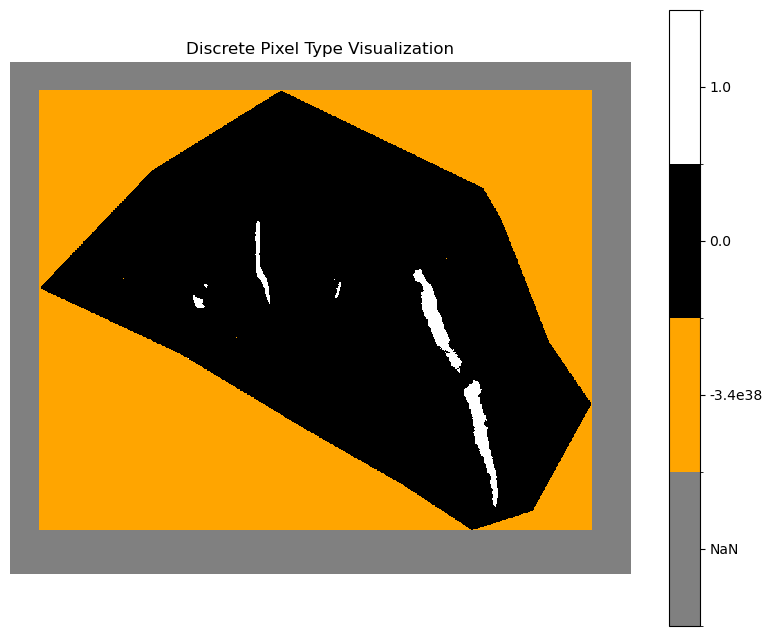

In [7]:
tif_path = r"C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\DeerCreekTrail\DeerCreekTrail_2020_05_23_snowbinary.tif" 
visualize_mask_values(tif_path)

Pixel Type Counts:
NaN: 0 pixels (0.00%)
-3.4e38: 0 pixels (0.00%)
0.0: 334561869 pixels (47.67%)
1.0: 44308 pixels (0.01%)


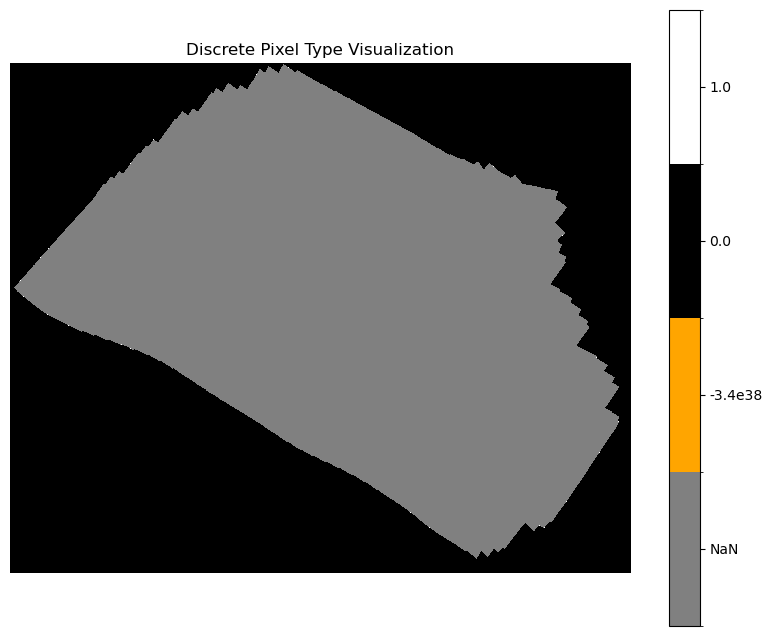

In [8]:
tif_path = r"C:\Users\jaydb\UCB-O365\Travis Hainsworth - RMBL\2 - Source Data\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2020_05_05_snow.tif"
visualize_mask_values(tif_path)

Pixel Type Counts:
NaN: 0 pixels (0.00%)
-3.4e38: 0 pixels (0.00%)
0.0: 365298525 pixels (50.44%)
1.0: 137047 pixels (0.02%)


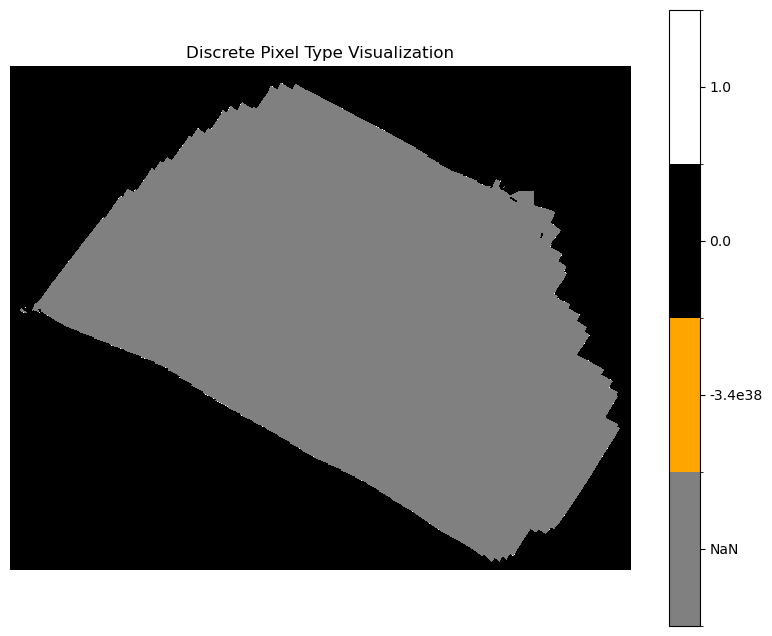

In [9]:
tif_path = r"C:\Users\jaydb\UCB-O365\Travis Hainsworth - RMBL\2 - Source Data\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2020_05_12_snow.tif"
visualize_mask_values(tif_path)